<a href="https://colab.research.google.com/github/vanshitpereira/fruit-classification-ml/blob/main/notebooks/01_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
%pip install -q opencv-python scikit-image scikit-learn pandas numpy matplotlib seaborn joblib scipy tqdm kagglehub

In [87]:
import cv2
import numpy as np
import pandas as pd
import os
import time
import joblib
import sklearn
import skimage
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Scikit-image:", skimage.__version__)

print("\nAll libraries imported successfully!")

OpenCV: 5.0.0
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Scikit-image: 0.25.2

All libraries imported successfully!


In [88]:
%pip install -q kagglehub

import kagglehub

print("KaggleHub installed successfully!")

KaggleHub installed successfully!


In [89]:
from google.colab import userdata

KAGGLE_API_TOKEN = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle token loaded successfully!")

Kaggle token loaded successfully!


In [90]:
import os

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

print("✅ Kaggle authentication configured")

✅ Kaggle authentication configured


In [91]:
path = kagglehub.dataset_download("moltean/fruits")

print("Dataset path:")
print(path)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset path:
/kaggle/input/fruits


In [92]:
import os

print("Dataset path:")
print(path)

print("\nContents:")
print(os.listdir(path))

Dataset path:
/kaggle/input/fruits

Contents:
['fruits-360_100x100', 'fruits-360_3-body-problem', 'fruits-360_meta', 'fruits-360_original-size', 'fruits-360_multi']


In [93]:
import os

dataset_100 = os.path.join(path, "fruits-360_100x100")

print("100x100 dataset contents:")
print(os.listdir(dataset_100))

100x100 dataset contents:
['fruits-360']


In [94]:
dataset_100 = os.path.join(
    path,
    "fruits-360_100x100",
    "fruits-360"
)

training_path = os.path.join(
    dataset_100,
    "Training"
)

test_path = os.path.join(
    dataset_100,
    "Test"
)

print("Training path:", training_path)
print("Test path:", test_path)

print("\nTraining exists:", os.path.exists(training_path))
print("Test exists:", os.path.exists(test_path))

Training path: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test path: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test

Training exists: True
Test exists: True


In [95]:
print("Number of training classes:", len(os.listdir(training_path)))
print("Number of test classes:", len(os.listdir(test_path)))

print("\nFirst 20 classes:")
print(sorted(os.listdir(training_path))[:20])

Number of training classes: 262
Number of test classes: 262

First 20 classes:
['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20', 'Apple 21', 'Apple 22', 'Apple 23', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Crimson Snow 1']


In [96]:
train_counts = {
    cls: len(os.listdir(os.path.join(training_path, cls)))
    for cls in os.listdir(training_path)
}

test_counts = {
    cls: len(os.listdir(os.path.join(test_path, cls)))
    for cls in os.listdir(test_path)
}

print("Total training images:", sum(train_counts.values()))
print("Total test images:", sum(test_counts.values()))

print("\nTraining image statistics:")
print("Minimum:", min(train_counts.values()))
print("Maximum:", max(train_counts.values()))
print(
    "Average:",
    round(sum(train_counts.values()) / len(train_counts), 2)
)

Total training images: 138642
Total test images: 46196

Training image statistics:
Minimum: 144
Maximum: 984
Average: 529.17


In [100]:
import os

print("Training folders:")
print(sorted(os.listdir(training_path)))

print("\nTest folders:")
print(sorted(os.listdir(test_path)))

Training folders:
['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20', 'Apple 21', 'Apple 22', 'Apple 23', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Crimson Snow 1', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3', 'Apple Granny Smith 1', 'Apple Pink Lady 1', 'Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Red Delicious 1', 'Apple Red Yellow 1', 'Apple Red Yellow 2', 'Apricot 1', 'Avocado 1', 'Avocado 2', 'Avocado Black 1', 'Avocado Black 2', 'Avocado Green 1', 'Banana 1', 'Banana 3', 'Banana 4', 'Banana Lady Finger 1', 'Banana Red 1', 'Bean pod 1', 'Beetroot 1', 'BlackBerry 4', 'Blackberry 1', 'Blackberry 2', 'Blackberry 3', 'Blackberry 5', 'Blueberry 1', 'Cabbage red 1', 'Cabbage white 1', 'Cactus fruit 1', 'Cactus fruit green 1', 'Cactus fruit red 1', 'Caju seed 1', 'Cantaloupe 1', 'Cantaloupe 2', 'Cantaloupe 3', 'Carambola 1', 'Carambola 2', 'Carambola 3', 'Carrot 1

In [101]:
selected_classes = [
    "Apple 10",
    "Banana 1",
    "Orange 1",
    "Pear 1",
    "Strawberry 1",
    "Pineapple 1",
    "Watermelon 1"
]

print("Selected classes:\n")

for cls in selected_classes:
    train_count = len(os.listdir(os.path.join(training_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    print(f"{cls:20s} -> Train: {train_count:4d} | Test: {test_count:4d}")

Selected classes:

Apple 10             -> Train:  699 | Test:  231
Banana 1             -> Train:  490 | Test:  166
Orange 1             -> Train:  479 | Test:  160
Pear 1               -> Train:  492 | Test:  164
Strawberry 1         -> Train:  492 | Test:  164
Pineapple 1          -> Train:  490 | Test:  166
Watermelon 1         -> Train:  475 | Test:  157


In [102]:
IMG_SIZE = 100

X_train = []
y_train = []

X_test = []
y_test = []

print("Loading training images...")

for label, class_name in enumerate(selected_classes):

    class_path = os.path.join(
        training_path,
        class_name
    )

    for filename in os.listdir(class_path):

        image_path = os.path.join(
            class_path,
            filename
        )

        image = cv2.imread(image_path)

        if image is not None:

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )

            image = cv2.resize(
                image,
                (IMG_SIZE, IMG_SIZE)
            )

            X_train.append(image)
            y_train.append(label)


print("Loading test images...")

for label, class_name in enumerate(selected_classes):

    class_path = os.path.join(
        test_path,
        class_name
    )

    for filename in os.listdir(class_path):

        image_path = os.path.join(
            class_path,
            filename
        )

        image = cv2.imread(image_path)

        if image is not None:

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )

            image = cv2.resize(
                image,
                (IMG_SIZE, IMG_SIZE)
            )

            X_test.append(image)
            y_test.append(label)


X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nDataset loaded successfully!")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading training images...
Loading test images...

Dataset loaded successfully!
X_train shape: (3617, 100, 100, 3)
y_train shape: (3617,)
X_test shape: (1208, 100, 100, 3)
y_test shape: (1208,)


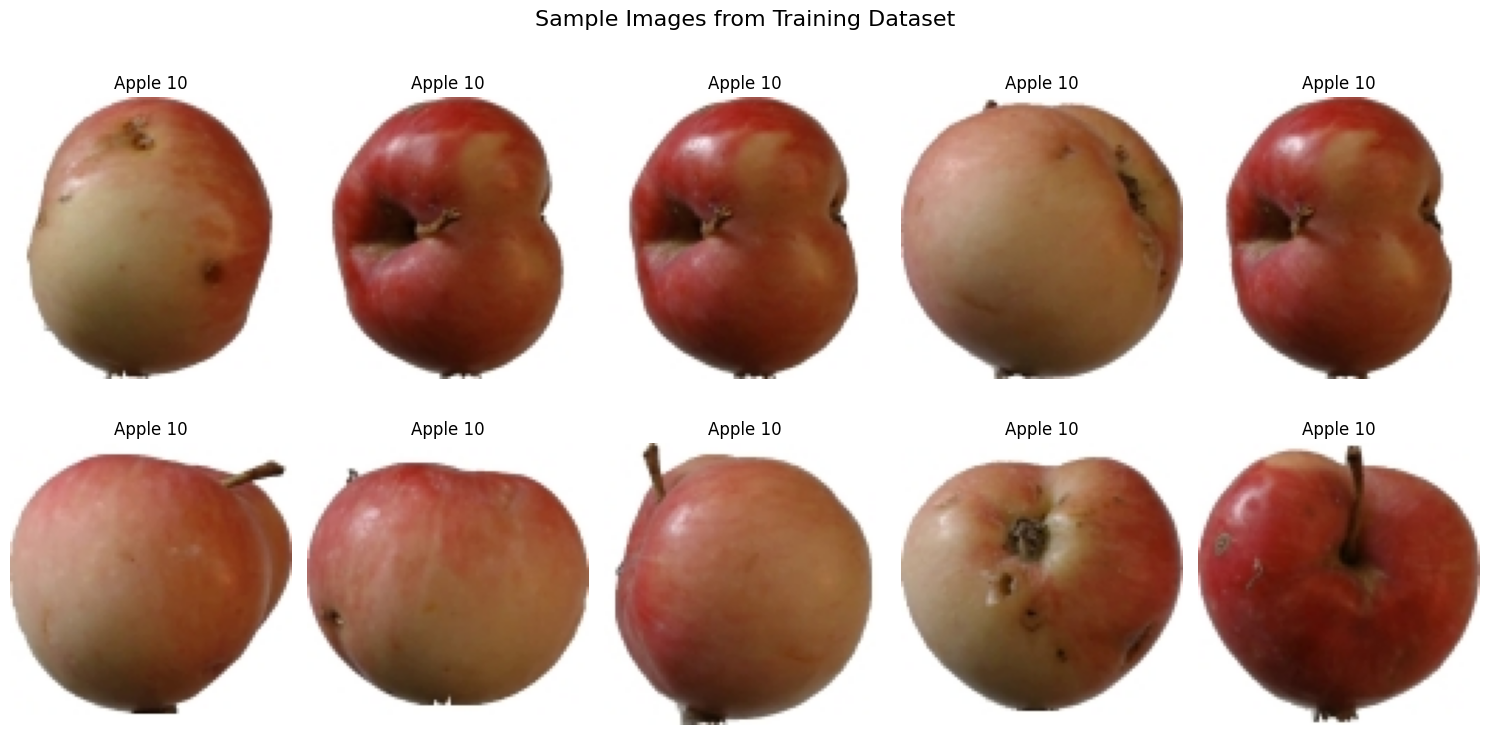

In [103]:
plt.figure(figsize=(15, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i])

    plt.title(
        selected_classes[y_train[i]]
    )

    plt.axis("off")

plt.suptitle(
    "Sample Images from Training Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [104]:
train_distribution = Counter(y_train)
test_distribution = Counter(y_test)

print("Training class distribution:")

for label, count in sorted(
    train_distribution.items()
):
    print(
        f"{selected_classes[label]:20s}: {count}"
    )


print("\nTest class distribution:")

for label, count in sorted(
    test_distribution.items()
):
    print(
        f"{selected_classes[label]:20s}: {count}"
    )

Training class distribution:
Apple 10            : 699
Banana 1            : 490
Orange 1            : 479
Pear 1              : 492
Strawberry 1        : 492
Pineapple 1         : 490
Watermelon 1        : 475

Test class distribution:
Apple 10            : 231
Banana 1            : 166
Orange 1            : 160
Pear 1              : 164
Strawberry 1        : 164
Pineapple 1         : 166
Watermelon 1        : 157


In [105]:
def preprocess_image(image):

    # Ensure uint8 format
    image = np.clip(
        image,
        0,
        255
    ).astype(np.uint8)

    # Convert RGB to LAB
    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    # CLAHE on L channel for lighting normalization
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_channel = clahe.apply(l_channel)

    lab = cv2.merge(
        [l_channel, a_channel, b_channel]
    )

    # Convert back to RGB
    processed = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB
    )

    # Mild Gaussian smoothing
    processed = cv2.GaussianBlur(
        processed,
        (3, 3),
        0
    )

    return processed


sample_processed = preprocess_image(
    X_train[0]
)

print(
    "Original image shape:",
    X_train[0].shape
)

print(
    "Processed image shape:",
    sample_processed.shape
)

print(
    "Processed pixel range:",
    sample_processed.min(),
    "to",
    sample_processed.max()
)

print("\nImproved preprocessing completed!")

Original image shape: (100, 100, 3)
Processed image shape: (100, 100, 3)
Processed pixel range: 6 to 255

Improved preprocessing completed!


In [106]:
from skimage.feature import hog, local_binary_pattern


def extract_features(image):

    features = []

    # =================================================
    # PREPROCESSING
    # =================================================

    image = preprocess_image(image)

    # =================================================
    # 1. RGB COLOR FEATURES
    # =================================================

    rgb_mean = np.mean(
        image,
        axis=(0, 1)
    )

    rgb_std = np.std(
        image,
        axis=(0, 1)
    )

    features.extend(rgb_mean)
    features.extend(rgb_std)

    # =================================================
    # 2. HSV COLOR FEATURES
    # =================================================

    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2HSV
    )

    hsv_mean = np.mean(
        hsv,
        axis=(0, 1)
    )

    hsv_std = np.std(
        hsv,
        axis=(0, 1)
    )

    features.extend(hsv_mean)
    features.extend(hsv_std)

    # =================================================
    # 3. GLOBAL COLOR HISTOGRAM
    # =================================================

    for channel in range(3):

        hist = cv2.calcHist(
            [image],
            [channel],
            None,
            [16],
            [0, 256]
        )

        hist = cv2.normalize(
            hist,
            hist
        ).flatten()

        features.extend(hist)

    # =================================================
    # 4. SPATIAL COLOR FEATURES
    # =================================================
    # Divide image into 4 regions.
    # This preserves information about where
    # colors occur in the image.

    h, w = image.shape[:2]

    regions = [
        image[:h//2, :w//2],
        image[:h//2, w//2:],
        image[h//2:, :w//2],
        image[h//2:, w//2:]
    ]

    for region in regions:

        region_mean = np.mean(
            region,
            axis=(0, 1)
        )

        region_std = np.std(
            region,
            axis=(0, 1)
        )

        features.extend(region_mean)
        features.extend(region_std)

    # =================================================
    # 5. HOG FEATURES
    # =================================================

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    features.extend(hog_features)

    # =================================================
    # 6. LBP TEXTURE - SCALE 1
    # =================================================

    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(
        gray,
        n_points,
        radius,
        method="uniform"
    )

    n_bins = n_points + 2

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins)
    )

    lbp_hist = lbp_hist.astype(
        "float32"
    )

    lbp_hist /= (
        lbp_hist.sum() + 1e-7
    )

    features.extend(lbp_hist)

    # =================================================
    # 7. LBP TEXTURE - SCALE 2
    # =================================================

    radius = 2
    n_points = 16

    lbp = local_binary_pattern(
        gray,
        n_points,
        radius,
        method="uniform"
    )

    n_bins = n_points + 2

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins)
    )

    lbp_hist = lbp_hist.astype(
        "float32"
    )

    lbp_hist /= (
        lbp_hist.sum() + 1e-7
    )

    features.extend(lbp_hist)

    # =================================================
    # 8. SHAPE / CONTOUR FEATURES
    # =================================================

    # Otsu thresholding
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        contour = max(
            contours,
            key=cv2.contourArea
        )

        area = cv2.contourArea(
            contour
        )

        perimeter = cv2.arcLength(
            contour,
            True
        )

        x, y, width, height = cv2.boundingRect(
            contour
        )

        aspect_ratio = (
            width / height
            if height > 0
            else 0
        )

        rectangular_area = width * height

        extent = (
            area / rectangular_area
            if rectangular_area > 0
            else 0
        )

        hull = cv2.convexHull(
            contour
        )

        hull_area = cv2.contourArea(
            hull
        )

        solidity = (
            area / hull_area
            if hull_area > 0
            else 0
        )

        circularity = (
            4 * np.pi * area /
            (perimeter ** 2)
            if perimeter > 0
            else 0
        )

        normalized_area = (
            area / (IMG_SIZE * IMG_SIZE)
        )

        normalized_perimeter = (
            perimeter /
            (2 * (IMG_SIZE + IMG_SIZE))
        )

        shape_features = [
            normalized_area,
            normalized_perimeter,
            aspect_ratio,
            extent,
            solidity,
            circularity
        ]

    else:

        shape_features = [
            0, 0, 0, 0, 0, 0
        ]

    features.extend(
        shape_features
    )

    return np.array(
        features,
        dtype=np.float32
    )


sample_features = extract_features(
    X_train[0]
)

print("Improved feature extraction successful!")

print(
    "Feature vector shape:",
    sample_features.shape
)

print(
    "Number of features:",
    len(sample_features)
)

Improved feature extraction successful!
Feature vector shape: (4474,)
Number of features: 4474


In [107]:
print("Extracting training features...")

X_train_features = []

for image in tqdm(X_train):

    X_train_features.append(
        extract_features(image)
    )


X_train_features = np.array(
    X_train_features
)


print("\nExtracting test features...")

X_test_features = []

for image in tqdm(X_test):

    X_test_features.append(
        extract_features(image)
    )


X_test_features = np.array(
    X_test_features
)


print("\nFeature extraction completed!")

print(
    "Training feature shape:",
    X_train_features.shape
)

print(
    "Test feature shape:",
    X_test_features.shape
)

Extracting training features...


100%|██████████| 3617/3617 [01:10<00:00, 51.00it/s]



Extracting test features...


100%|██████████| 1208/1208 [00:22<00:00, 54.26it/s]



Feature extraction completed!
Training feature shape: (3617, 4474)
Test feature shape: (1208, 4474)


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# IMPORTANT:
# Fit only on training data
X_train_scaled = scaler.fit_transform(
    X_train_features
)

# Apply same scaler to test data
X_test_scaled = scaler.transform(
    X_test_features
)

print("Feature scaling completed!")

print(
    "Scaled training shape:",
    X_train_scaled.shape
)

print(
    "Scaled test shape:",
    X_test_scaled.shape
)

print(
    "\nTraining feature mean:",
    np.mean(X_train_scaled)
)

print(
    "Training feature standard deviation:",
    np.std(X_train_scaled)
)

Feature scaling completed!
Scaled training shape: (3617, 4474)
Scaled test shape: (1208, 4474)

Training feature mean: -7.941286e-09
Training feature standard deviation: 1.0


In [109]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {}

print("Training SVM...")

start = time.time()

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_time = time.time() - start

svm_pred = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(
    f"SVM Accuracy: "
    f"{svm_accuracy * 100:.2f}%"
)

print(
    f"SVM Training Time: "
    f"{svm_time:.2f} seconds"
)


print("\nTraining KNN...")

start = time.time()

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_time = time.time() - start

knn_pred = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print(
    f"KNN Accuracy: "
    f"{knn_accuracy * 100:.2f}%"
)

print(
    f"KNN Training Time: "
    f"{knn_time:.2f} seconds"
)


print("\nTraining Decision Tree...")

start = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=2,
    random_state=42
)

dt_model.fit(
    X_train_scaled,
    y_train
)

dt_time = time.time() - start

dt_pred = dt_model.predict(
    X_test_scaled
)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    f"Decision Tree Accuracy: "
    f"{dt_accuracy * 100:.2f}%"
)

print(
    f"Decision Tree Training Time: "
    f"{dt_time:.2f} seconds"
)


print("\nTraining Random Forest...")

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=30,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_time = time.time() - start

rf_pred = rf_model.predict(
    X_test_scaled
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy * 100:.2f}%"
)

print(
    f"Random Forest Training Time: "
    f"{rf_time:.2f} seconds"
)


models["SVM"] = svm_model
models["KNN"] = knn_model
models["Decision Tree"] = dt_model
models["Random Forest"] = rf_model

print("\n===================================")
print("ALL CLASSIFIERS TRAINED SUCCESSFULLY")
print("===================================")

Training SVM...
SVM Accuracy: 99.42%
SVM Training Time: 124.65 seconds

Training KNN...
KNN Accuracy: 94.87%
KNN Training Time: 0.01 seconds

Training Decision Tree...
Decision Tree Accuracy: 98.92%
Decision Tree Training Time: 8.82 seconds

Training Random Forest...
Random Forest Accuracy: 100.00%
Random Forest Training Time: 18.25 seconds

ALL CLASSIFIERS TRAINED SUCCESSFULLY


In [110]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

predictions = {
    "SVM": svm_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

results = []

for model_name, prediction in predictions.items():

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1-Score": f1 * 100
    })


results_df = pd.DataFrame(results)

print("MODEL PERFORMANCE")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)

MODEL PERFORMANCE
        Model   Accuracy  Precision     Recall   F1-Score
          SVM  99.420530  99.444819  99.420530  99.420414
          KNN  94.867550  95.560479  94.867550  94.787080
Decision Tree  98.923841  98.938299  98.923841  98.924774
Random Forest 100.000000 100.000000 100.000000 100.000000


In [111]:
baseline_results = pd.DataFrame({
    "Model": [
        "SVM",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Original Accuracy": [
        98.99,
        95.50,
        97.63,
        100.00
    ]
})

comparison_df = baseline_results.merge(
    results_df[
        ["Model", "Accuracy"]
    ],
    on="Model"
)

comparison_df.rename(
    columns={
        "Accuracy": "Improved Accuracy"
    },
    inplace=True
)

comparison_df["Change"] = (
    comparison_df["Improved Accuracy"]
    - comparison_df["Original Accuracy"]
)

print(
    comparison_df.to_string(
        index=False
    )
)

        Model  Original Accuracy  Improved Accuracy    Change
          SVM              98.99          99.420530  0.430530
          KNN              95.50          94.867550 -0.632450
Decision Tree              97.63          98.923841  1.293841
Random Forest             100.00         100.000000  0.000000


In [112]:
print("Random Forest Classification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=selected_classes,
        digits=4
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

    Apple 10     1.0000    1.0000    1.0000       231
    Banana 1     1.0000    1.0000    1.0000       166
    Orange 1     1.0000    1.0000    1.0000       160
      Pear 1     1.0000    1.0000    1.0000       164
Strawberry 1     1.0000    1.0000    1.0000       164
 Pineapple 1     1.0000    1.0000    1.0000       166
Watermelon 1     1.0000    1.0000    1.0000       157

    accuracy                         1.0000      1208
   macro avg     1.0000    1.0000    1.0000      1208
weighted avg     1.0000    1.0000    1.0000      1208



In [113]:
from scipy.stats import mode

all_predictions = np.vstack([
    svm_pred,
    knn_pred,
    dt_pred,
    rf_pred
])

print(
    "Prediction matrix shape:",
    all_predictions.shape
)

ensemble_pred, vote_count = mode(
    all_predictions,
    axis=0,
    keepdims=False
)

ensemble_pred = ensemble_pred.astype(int)

ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_pred
)

print("\n======================================")
print("HARD MAJORITY VOTING ENSEMBLE")
print("======================================")

print(
    "Ensemble Accuracy:",
    f"{ensemble_accuracy * 100:.2f}%"
)

print(
    "Correct Predictions:",
    np.sum(
        ensemble_pred == y_test
    )
)

print(
    "Incorrect Predictions:",
    np.sum(
        ensemble_pred != y_test
    )
)

Prediction matrix shape: (4, 1208)

HARD MAJORITY VOTING ENSEMBLE
Ensemble Accuracy: 99.42%
Correct Predictions: 1201
Incorrect Predictions: 7


In [114]:
ensemble_precision = precision_score(
    y_test,
    ensemble_pred,
    average="weighted",
    zero_division=0
)

ensemble_recall = recall_score(
    y_test,
    ensemble_pred,
    average="weighted",
    zero_division=0
)

ensemble_f1 = f1_score(
    y_test,
    ensemble_pred,
    average="weighted",
    zero_division=0
)

print("HARD MAJORITY VOTING PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy  : "
    f"{ensemble_accuracy * 100:.2f}%"
)

print(
    f"Precision : "
    f"{ensemble_precision * 100:.2f}%"
)

print(
    f"Recall    : "
    f"{ensemble_recall * 100:.2f}%"
)

print(
    f"F1-Score  : "
    f"{ensemble_f1 * 100:.2f}%"
)

HARD MAJORITY VOTING PERFORMANCE
Accuracy  : 99.42%
Precision : 99.44%
Recall    : 99.42%
F1-Score  : 99.42%


In [115]:
print("ENSEMBLE COMPARISON")
print("=" * 60)

print(
    f"Original Ensemble Accuracy : 99.70%"
)

print(
    f"Improved Ensemble Accuracy : "
    f"{ensemble_accuracy * 100:.2f}%"
)

print(
    f"Change : "
    f"{(ensemble_accuracy * 100) - 99.70:.2f}%"
)

ENSEMBLE COMPARISON
Original Ensemble Accuracy : 99.70%
Improved Ensemble Accuracy : 99.42%
Change : -0.28%


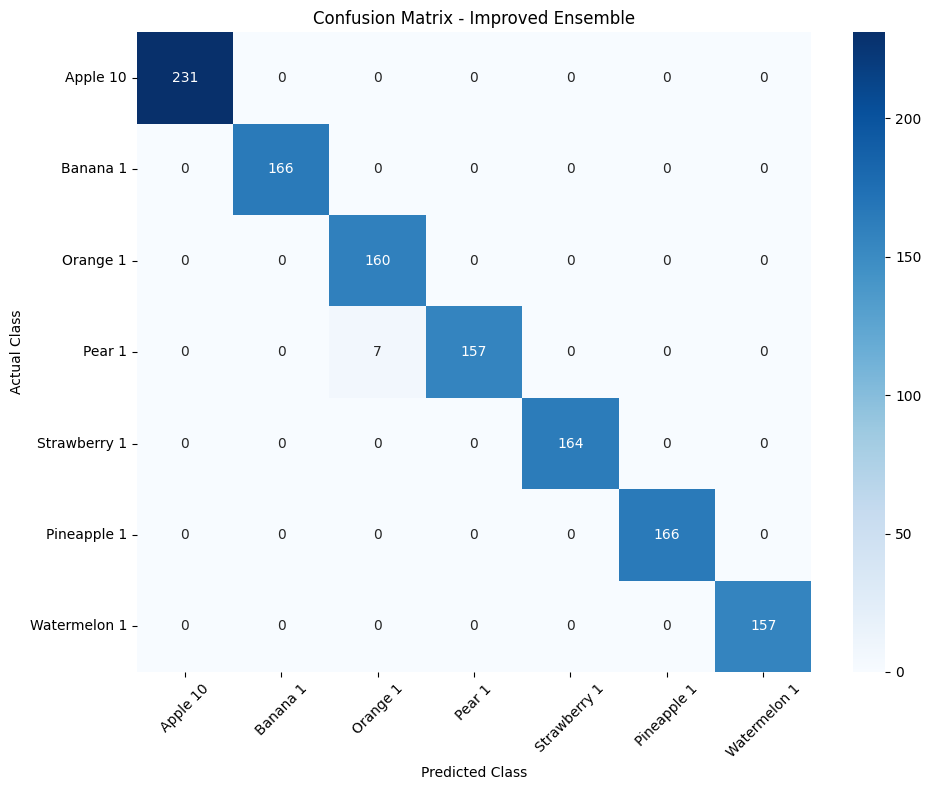

In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    ensemble_pred
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=selected_classes,
    yticklabels=selected_classes
)

plt.title(
    "Confusion Matrix - Improved Ensemble"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    rotation=45
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [117]:
incorrect_indices = np.where(
    ensemble_pred != y_test
)[0]

print(
    "Number of incorrect predictions:",
    len(incorrect_indices)
)

print("\nIncorrect Predictions:")
print("=" * 70)

for idx in incorrect_indices:

    print(
        f"Actual: "
        f"{selected_classes[y_test[idx]]:15s} | "
        f"Predicted: "
        f"{selected_classes[ensemble_pred[idx]]}"
    )

Number of incorrect predictions: 7

Incorrect Predictions:
Actual: Pear 1          | Predicted: Orange 1
Actual: Pear 1          | Predicted: Orange 1
Actual: Pear 1          | Predicted: Orange 1
Actual: Pear 1          | Predicted: Orange 1
Actual: Pear 1          | Predicted: Orange 1
Actual: Pear 1          | Predicted: Orange 1
Actual: Pear 1          | Predicted: Orange 1


In [118]:
# Step 22: Save Trained Models and Preprocessing Components

import os
import joblib

# Create models directory
os.makedirs("models", exist_ok=True)

# Save trained classifiers
joblib.dump(svm_model, "models/svm_model.pkl")
joblib.dump(knn_model, "models/knn_model.pkl")
joblib.dump(dt_model, "models/decision_tree_model.pkl")
joblib.dump(rf_model, "models/random_forest_model.pkl")

# Save the feature scaler
joblib.dump(scaler, "models/scaler.pkl")

# Save class labels
joblib.dump(selected_classes, "models/class_labels.pkl")

print("======================================")
print("MODELS SAVED SUCCESSFULLY")
print("======================================")

print("SVM                  : models/svm_model.pkl")
print("KNN                  : models/knn_model.pkl")
print("Decision Tree        : models/decision_tree_model.pkl")
print("Random Forest        : models/random_forest_model.pkl")
print("Scaler               : models/scaler.pkl")
print("Class Labels         : models/class_labels.pkl")

MODELS SAVED SUCCESSFULLY
SVM                  : models/svm_model.pkl
KNN                  : models/knn_model.pkl
Decision Tree        : models/decision_tree_model.pkl
Random Forest        : models/random_forest_model.pkl
Scaler               : models/scaler.pkl
Class Labels         : models/class_labels.pkl


In [119]:
# Step 23: Load Pretrained MobileNetV2

import tensorflow as tf
import numpy as np
import time

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# Pretrained ImageNet MobileNetV2
cnn_feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# Freeze CNN weights because we only need deep features
cnn_feature_extractor.trainable = False

print("\nMobileNetV2 loaded successfully!")
print("Input shape :", cnn_feature_extractor.input_shape)
print("Output shape:", cnn_feature_extractor.output_shape)
print("Trainable   :", cnn_feature_extractor.trainable)


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

MobileNetV2 loaded successfully!
Input shape : (None, 224, 224, 3)
Output shape: (None, 1280)
Trainable   : False


In [120]:
# Step 24: CNN Feature Extraction Function

def extract_cnn_features(images, batch_size=64):
    """
    Convert RGB images into MobileNetV2 deep feature vectors.

    Input:
        images -> NumPy array of RGB uint8 images, normally 100x100x3

    Output:
        NumPy array of shape (number_of_images, 1280)
    """

    all_features = []

    for start in range(0, len(images), batch_size):
        batch = images[start:start + batch_size]

        # Resize 100x100 images to MobileNetV2's expected 224x224 size
        batch = tf.image.resize(
            batch,
            (224, 224),
            method="bilinear"
        )

        batch = tf.cast(batch, tf.float32)

        # MobileNetV2 preprocessing: pixels -> [-1, 1]
        batch = preprocess_input(batch)

        # Extract 1280-dimensional deep features
        features = cnn_feature_extractor.predict(
            batch,
            verbose=0
        )

        all_features.append(features)

        print(
            f"Processed {min(start + batch_size, len(images))}/{len(images)} images"
        )

    return np.vstack(all_features).astype(np.float32)


sample_cnn_features = extract_cnn_features(X_train[:1], batch_size=1)

print("\nCNN feature extraction test successful!")
print("Feature shape:", sample_cnn_features.shape)
print("Number of features:", sample_cnn_features.shape[1])


Processed 1/1 images

CNN feature extraction test successful!
Feature shape: (1, 1280)
Number of features: 1280


In [121]:
# Step 25: Extract CNN Features from Training and Test Data

print("Starting CNN feature extraction...")
print("This uses the existing X_train and X_test arrays above.")
print()

cnn_start = time.time()

print("Extracting TRAINING CNN features...")
X_train_cnn = extract_cnn_features(X_train, batch_size=64)

print("\nExtracting TEST CNN features...")
X_test_cnn = extract_cnn_features(X_test, batch_size=64)

cnn_feature_time = time.time() - cnn_start

print("\n======================================")
print("CNN FEATURE EXTRACTION COMPLETED")
print("======================================")
print("Training CNN feature shape:", X_train_cnn.shape)
print("Test CNN feature shape    :", X_test_cnn.shape)
print(f"Total extraction time     : {cnn_feature_time:.2f} seconds")


Starting CNN feature extraction...
This uses the existing X_train and X_test arrays above.

Extracting TRAINING CNN features...
Processed 64/3617 images
Processed 128/3617 images
Processed 192/3617 images
Processed 256/3617 images
Processed 320/3617 images
Processed 384/3617 images
Processed 448/3617 images
Processed 512/3617 images
Processed 576/3617 images
Processed 640/3617 images
Processed 704/3617 images
Processed 768/3617 images
Processed 832/3617 images
Processed 896/3617 images
Processed 960/3617 images
Processed 1024/3617 images
Processed 1088/3617 images
Processed 1152/3617 images
Processed 1216/3617 images
Processed 1280/3617 images
Processed 1344/3617 images
Processed 1408/3617 images
Processed 1472/3617 images
Processed 1536/3617 images
Processed 1600/3617 images
Processed 1664/3617 images
Processed 1728/3617 images
Processed 1792/3617 images
Processed 1856/3617 images
Processed 1920/3617 images
Processed 1984/3617 images
Processed 2048/3617 images
Processed 2112/3617 imag

In [122]:
# Step 26: Scale CNN Features

from sklearn.preprocessing import StandardScaler

cnn_scaler = StandardScaler()

# Fit ONLY on training CNN features
X_train_cnn_scaled = cnn_scaler.fit_transform(X_train_cnn)

# Apply the same scaler to test CNN features
X_test_cnn_scaled = cnn_scaler.transform(X_test_cnn)

print("CNN feature scaling completed!")
print("Scaled training shape:", X_train_cnn_scaled.shape)
print("Scaled test shape    :", X_test_cnn_scaled.shape)
print("Training mean        :", np.mean(X_train_cnn_scaled))
print("Training std         :", np.std(X_train_cnn_scaled))


CNN feature scaling completed!
Scaled training shape: (3617, 1280)
Scaled test shape    : (1208, 1280)
Training mean        : 7.2307915e-09
Training std         : 1.0000002


In [123]:
# Step 27: Train the Same Four Classifiers on CNN Features

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

cnn_models = {}
cnn_predictions = {}
cnn_training_times = {}

# -------------------------------------------------
# 1. SVM
# -------------------------------------------------

print("Training CNN + SVM...")
start = time.time()

cnn_svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

cnn_svm_model.fit(X_train_cnn_scaled, y_train)

cnn_svm_time = time.time() - start
cnn_svm_pred = cnn_svm_model.predict(X_test_cnn_scaled)

cnn_models["SVM"] = cnn_svm_model
cnn_predictions["SVM"] = cnn_svm_pred
cnn_training_times["SVM"] = cnn_svm_time

print(f"CNN + SVM Accuracy: {accuracy_score(y_test, cnn_svm_pred) * 100:.2f}%")
print(f"Training time: {cnn_svm_time:.2f} seconds")


# -------------------------------------------------
# 2. KNN
# -------------------------------------------------

print("\nTraining CNN + KNN...")
start = time.time()

cnn_knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

cnn_knn_model.fit(X_train_cnn_scaled, y_train)

cnn_knn_time = time.time() - start
cnn_knn_pred = cnn_knn_model.predict(X_test_cnn_scaled)

cnn_models["KNN"] = cnn_knn_model
cnn_predictions["KNN"] = cnn_knn_pred
cnn_training_times["KNN"] = cnn_knn_time

print(f"CNN + KNN Accuracy: {accuracy_score(y_test, cnn_knn_pred) * 100:.2f}%")
print(f"Training time: {cnn_knn_time:.2f} seconds")


# -------------------------------------------------
# 3. DECISION TREE
# -------------------------------------------------

print("\nTraining CNN + Decision Tree...")
start = time.time()

cnn_dt_model = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=2,
    random_state=42
)

cnn_dt_model.fit(X_train_cnn_scaled, y_train)

cnn_dt_time = time.time() - start
cnn_dt_pred = cnn_dt_model.predict(X_test_cnn_scaled)

cnn_models["Decision Tree"] = cnn_dt_model
cnn_predictions["Decision Tree"] = cnn_dt_pred
cnn_training_times["Decision Tree"] = cnn_dt_time

print(f"CNN + Decision Tree Accuracy: {accuracy_score(y_test, cnn_dt_pred) * 100:.2f}%")
print(f"Training time: {cnn_dt_time:.2f} seconds")


# -------------------------------------------------
# 4. RANDOM FOREST
# -------------------------------------------------

print("\nTraining CNN + Random Forest...")
start = time.time()

cnn_rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=30,
    n_jobs=-1,
    random_state=42
)

cnn_rf_model.fit(X_train_cnn_scaled, y_train)

cnn_rf_time = time.time() - start
cnn_rf_pred = cnn_rf_model.predict(X_test_cnn_scaled)

cnn_models["Random Forest"] = cnn_rf_model
cnn_predictions["Random Forest"] = cnn_rf_pred
cnn_training_times["Random Forest"] = cnn_rf_time

print(f"CNN + Random Forest Accuracy: {accuracy_score(y_test, cnn_rf_pred) * 100:.2f}%")
print(f"Training time: {cnn_rf_time:.2f} seconds")


print("\n======================================")
print("ALL CNN-BASED CLASSIFIERS TRAINED")
print("======================================")


Training CNN + SVM...
CNN + SVM Accuracy: 99.92%
Training time: 9.49 seconds

Training CNN + KNN...
CNN + KNN Accuracy: 99.92%
Training time: 0.00 seconds

Training CNN + Decision Tree...
CNN + Decision Tree Accuracy: 97.19%
Training time: 2.72 seconds

Training CNN + Random Forest...
CNN + Random Forest Accuracy: 100.00%
Training time: 6.03 seconds

ALL CNN-BASED CLASSIFIERS TRAINED


In [124]:
# Step 28: CNN Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

cnn_results = []

for model_name, prediction in cnn_predictions.items():
    cnn_results.append({
        "Model": "CNN + " + model_name,
        "Accuracy": accuracy_score(y_test, prediction) * 100,
        "Precision": precision_score(
            y_test, prediction,
            average="weighted",
            zero_division=0
        ) * 100,
        "Recall": recall_score(
            y_test, prediction,
            average="weighted",
            zero_division=0
        ) * 100,
        "F1-Score": f1_score(
            y_test, prediction,
            average="weighted",
            zero_division=0
        ) * 100
    })

cnn_results_df = pd.DataFrame(cnn_results)

print("CNN-BASED MODEL PERFORMANCE")
print("=" * 75)
print(cnn_results_df.to_string(index=False))

print("\nCNN + Random Forest Classification Report")
print("=" * 75)
print(
    classification_report(
        y_test,
        cnn_rf_pred,
        target_names=selected_classes,
        digits=4
    )
)


CNN-BASED MODEL PERFORMANCE
              Model   Accuracy  Precision     Recall   F1-Score
          CNN + SVM  99.917219  99.917714  99.917219  99.917216
          CNN + KNN  99.917219  99.917714  99.917219  99.917218
CNN + Decision Tree  97.185430  97.183747  97.185430  97.181954
CNN + Random Forest 100.000000 100.000000 100.000000 100.000000

CNN + Random Forest Classification Report
              precision    recall  f1-score   support

    Apple 10     1.0000    1.0000    1.0000       231
    Banana 1     1.0000    1.0000    1.0000       166
    Orange 1     1.0000    1.0000    1.0000       160
      Pear 1     1.0000    1.0000    1.0000       164
Strawberry 1     1.0000    1.0000    1.0000       164
 Pineapple 1     1.0000    1.0000    1.0000       166
Watermelon 1     1.0000    1.0000    1.0000       157

    accuracy                         1.0000      1208
   macro avg     1.0000    1.0000    1.0000      1208
weighted avg     1.0000    1.0000    1.0000      1208



In [125]:
# Step 29: CNN Hard Majority Voting Ensemble

from scipy.stats import mode

cnn_all_predictions = np.vstack([
    cnn_svm_pred,
    cnn_knn_pred,
    cnn_dt_pred,
    cnn_rf_pred
])

print("CNN prediction matrix shape:", cnn_all_predictions.shape)

cnn_ensemble_pred, cnn_vote_count = mode(
    cnn_all_predictions,
    axis=0,
    keepdims=False
)

cnn_ensemble_pred = cnn_ensemble_pred.astype(int)

cnn_ensemble_accuracy = accuracy_score(
    y_test,
    cnn_ensemble_pred
)

cnn_ensemble_precision = precision_score(
    y_test,
    cnn_ensemble_pred,
    average="weighted",
    zero_division=0
)

cnn_ensemble_recall = recall_score(
    y_test,
    cnn_ensemble_pred,
    average="weighted",
    zero_division=0
)

cnn_ensemble_f1 = f1_score(
    y_test,
    cnn_ensemble_pred,
    average="weighted",
    zero_division=0
)

print("\n======================================")
print("CNN HARD MAJORITY VOTING ENSEMBLE")
print("======================================")

print(f"Accuracy  : {cnn_ensemble_accuracy * 100:.2f}%")
print(f"Precision : {cnn_ensemble_precision * 100:.2f}%")
print(f"Recall    : {cnn_ensemble_recall * 100:.2f}%")
print(f"F1-Score  : {cnn_ensemble_f1 * 100:.2f}%")
print("Correct   :", np.sum(cnn_ensemble_pred == y_test))
print("Incorrect :", np.sum(cnn_ensemble_pred != y_test))


CNN prediction matrix shape: (4, 1208)

CNN HARD MAJORITY VOTING ENSEMBLE
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%
Correct   : 1208
Incorrect : 0


In [126]:
# Step 30: Compare Original and CNN Approaches

# Original results_df was created earlier in this notebook.
# Original ensemble metrics were also calculated earlier.

original_comparison = results_df.copy()

cnn_comparison = cnn_results_df.copy()

comparison_df = pd.concat(
    [original_comparison, cnn_comparison],
    ignore_index=True
)

print("CLASSIFIER COMPARISON")
print("=" * 90)
print(comparison_df.to_string(index=False))

print("\nENSEMBLE COMPARISON")
print("=" * 70)

ensemble_comparison_df = pd.DataFrame([
    {
        "Approach": "Original handcrafted features + voting",
        "Accuracy": ensemble_accuracy * 100,
        "Precision": ensemble_precision * 100,
        "Recall": ensemble_recall * 100,
        "F1-Score": ensemble_f1 * 100
    },
    {
        "Approach": "MobileNetV2 CNN features + voting",
        "Accuracy": cnn_ensemble_accuracy * 100,
        "Precision": cnn_ensemble_precision * 100,
        "Recall": cnn_ensemble_recall * 100,
        "F1-Score": cnn_ensemble_f1 * 100
    }
])

print(ensemble_comparison_df.to_string(index=False))


CLASSIFIER COMPARISON
              Model   Accuracy  Precision     Recall   F1-Score
                SVM  99.420530  99.444819  99.420530  99.420414
                KNN  94.867550  95.560479  94.867550  94.787080
      Decision Tree  98.923841  98.938299  98.923841  98.924774
      Random Forest 100.000000 100.000000 100.000000 100.000000
          CNN + SVM  99.917219  99.917714  99.917219  99.917216
          CNN + KNN  99.917219  99.917714  99.917219  99.917218
CNN + Decision Tree  97.185430  97.183747  97.185430  97.181954
CNN + Random Forest 100.000000 100.000000 100.000000 100.000000

ENSEMBLE COMPARISON
                              Approach  Accuracy  Precision    Recall   F1-Score
Original handcrafted features + voting  99.42053  99.444819  99.42053  99.420414
     MobileNetV2 CNN features + voting 100.00000 100.000000 100.00000 100.000000


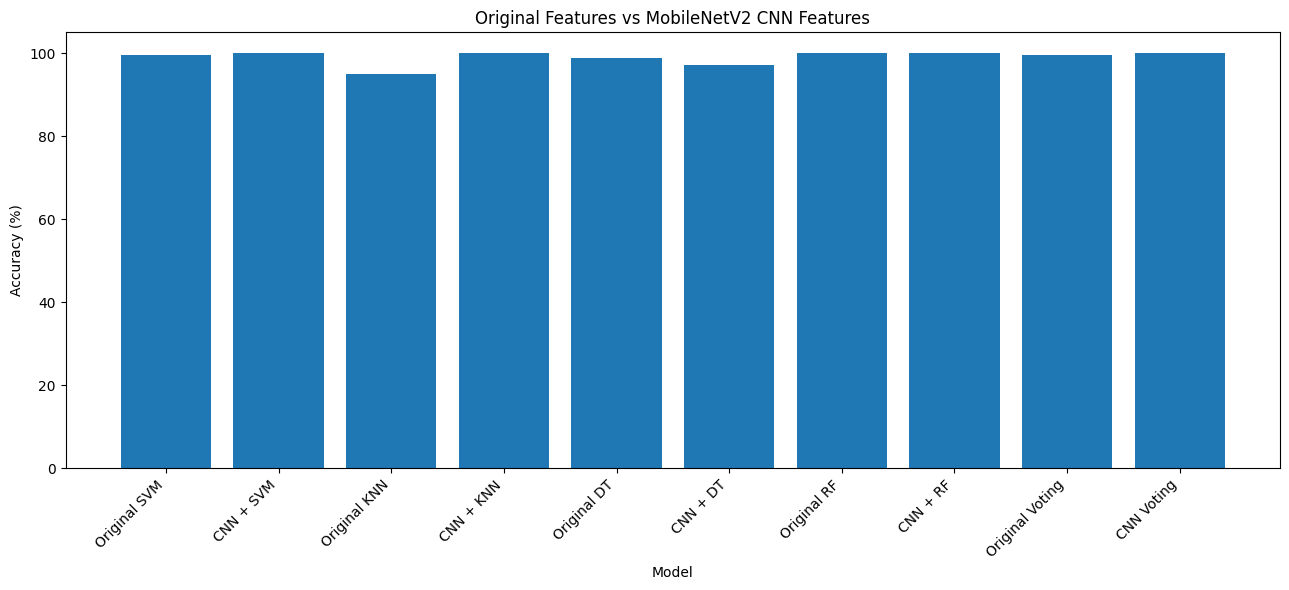

In [127]:
# Step 31: CNN Accuracy Comparison Plot

import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "Model": [
        "Original SVM",
        "CNN + SVM",
        "Original KNN",
        "CNN + KNN",
        "Original DT",
        "CNN + DT",
        "Original RF",
        "CNN + RF",
        "Original Voting",
        "CNN Voting"
    ],
    "Accuracy": [
        results_df.loc[results_df["Model"] == "SVM", "Accuracy"].iloc[0],
        cnn_results_df.loc[cnn_results_df["Model"] == "CNN + SVM", "Accuracy"].iloc[0],
        results_df.loc[results_df["Model"] == "KNN", "Accuracy"].iloc[0],
        cnn_results_df.loc[cnn_results_df["Model"] == "CNN + KNN", "Accuracy"].iloc[0],
        results_df.loc[results_df["Model"] == "Decision Tree", "Accuracy"].iloc[0],
        cnn_results_df.loc[cnn_results_df["Model"] == "CNN + Decision Tree", "Accuracy"].iloc[0],
        results_df.loc[results_df["Model"] == "Random Forest", "Accuracy"].iloc[0],
        cnn_results_df.loc[cnn_results_df["Model"] == "CNN + Random Forest", "Accuracy"].iloc[0],
        ensemble_accuracy * 100,
        cnn_ensemble_accuracy * 100
    ]
})

plt.figure(figsize=(13, 6))
plt.bar(plot_df["Model"], plot_df["Accuracy"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Original Features vs MobileNetV2 CNN Features")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


In [128]:
# Step 32: Save CNN Models Separately

import os
import joblib

os.makedirs("models_cnn", exist_ok=True)

joblib.dump(cnn_svm_model, "models_cnn/svm_cnn_model.pkl")
joblib.dump(cnn_knn_model, "models_cnn/knn_cnn_model.pkl")
joblib.dump(cnn_dt_model, "models_cnn/decision_tree_cnn_model.pkl")
joblib.dump(cnn_rf_model, "models_cnn/random_forest_cnn_model.pkl")

joblib.dump(cnn_scaler, "models_cnn/cnn_scaler.pkl")
joblib.dump(selected_classes, "models_cnn/class_labels_cnn.pkl")

print("======================================")
print("CNN MODELS SAVED SUCCESSFULLY")
print("======================================")
print("SVM                  : models_cnn/svm_cnn_model.pkl")
print("KNN                  : models_cnn/knn_cnn_model.pkl")
print("Decision Tree        : models_cnn/decision_tree_cnn_model.pkl")
print("Random Forest        : models_cnn/random_forest_cnn_model.pkl")
print("Scaler               : models_cnn/cnn_scaler.pkl")
print("Class Labels         : models_cnn/class_labels_cnn.pkl")

print("\nExisting models/ files were NOT overwritten.")


CNN MODELS SAVED SUCCESSFULLY
SVM                  : models_cnn/svm_cnn_model.pkl
KNN                  : models_cnn/knn_cnn_model.pkl
Decision Tree        : models_cnn/decision_tree_cnn_model.pkl
Random Forest        : models_cnn/random_forest_cnn_model.pkl
Scaler               : models_cnn/cnn_scaler.pkl
Class Labels         : models_cnn/class_labels_cnn.pkl

Existing models/ files were NOT overwritten.


In [133]:
# Step 33: Test CNN Model on Unseen Real-World Images

from google.colab import files
from IPython.display import display
from PIL import Image

print("Upload one or more unseen fruit images.")
uploaded = files.upload()

def predict_unseen_cnn_image(image_path):
    # Read image as RGB
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Extract exactly 1280 CNN features
    features = extract_cnn_features(
        np.expand_dims(image, axis=0),
        batch_size=1
    )

    # Scale using the scaler fitted on training data
    features_scaled = cnn_scaler.transform(features)

    # Predictions from all four classifiers
    svm_prediction = cnn_svm_model.predict(features_scaled)[0]
    knn_prediction = cnn_knn_model.predict(features_scaled)[0]
    dt_prediction = cnn_dt_model.predict(features_scaled)[0]
    rf_prediction = cnn_rf_model.predict(features_scaled)[0]

    prediction_matrix = np.array([
        svm_prediction,
        knn_prediction,
        dt_prediction,
        rf_prediction
    ]).reshape(4, 1)

    final_prediction, _ = mode(
        prediction_matrix,
        axis=0,
        keepdims=False
    )

    final_prediction = int(final_prediction[0])

    return {
        "SVM": selected_classes[int(svm_prediction)],
        "KNN": selected_classes[int(knn_prediction)],
        "Decision Tree": selected_classes[int(dt_prediction)],
        "Random Forest": selected_classes[int(rf_prediction)],
        "Final Voting": selected_classes[final_prediction]
    }


print("\nCNN UNSEEN-IMAGE PREDICTIONS")
print("=" * 75)

for filename in uploaded.keys():
    result = predict_unseen_cnn_image(filename)

    print(f"\nImage: {filename}")
    for model_name, prediction in result.items():
        print(f"{model_name:15s}: {prediction}")


Upload one or more unseen fruit images.



CNN UNSEEN-IMAGE PREDICTIONS
